In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [6]:
PROJECT_DIR   = Path.cwd().resolve().parent
EXTRACT_DIR   = PROJECT_DIR / 'processed' / 'extraction'
TRANSFORM_DIR = PROJECT_DIR / 'processed' / 'transform'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


timeseries_cohort = pd.read_csv(TRANSFORM_DIR / 'hourly_timeseries_60min.csv')
cohort_final      = pd.read_csv(TRANSFORM_DIR / 'cohort_final.csv')
cohort_flow       = pd.read_csv(TRANSFORM_DIR / 'cohort_attrition.csv')

for col in ['intime', 'outtime', 'admittime', 'dischtime', 'deathtime']:
    if col in cohort_final.columns:
        cohort_final[col] = pd.to_datetime(cohort_final[col], errors='coerce')

cohort_stay_ids = set(cohort_final['stay_id'])

print(f"Timeseries: {timeseries_cohort.shape}")
print(f"Cohort stays: {cohort_final['stay_id'].nunique():,}")
display(cohort_flow)

Timeseries: (74230, 69)
Cohort stays: 573


,step,n_subjects,n_hadm,n_stays,timeseries_rows,assessment_rows,stays_removed_from_previous,stays_pct_of_initial
0,0. All ICU stays from extraction,568,850,974,86648,5854,0,100.000000
1,1. Positive ICU LOS,568,850,974,86648,5854,0,100.000000
2,2. ICU LOS >= 24 hours,489,690,775,83689,5588,199,79.568789
3,3. Delirium assessment available after 24 hours,390,514,573,74230,5320,202,58.829569


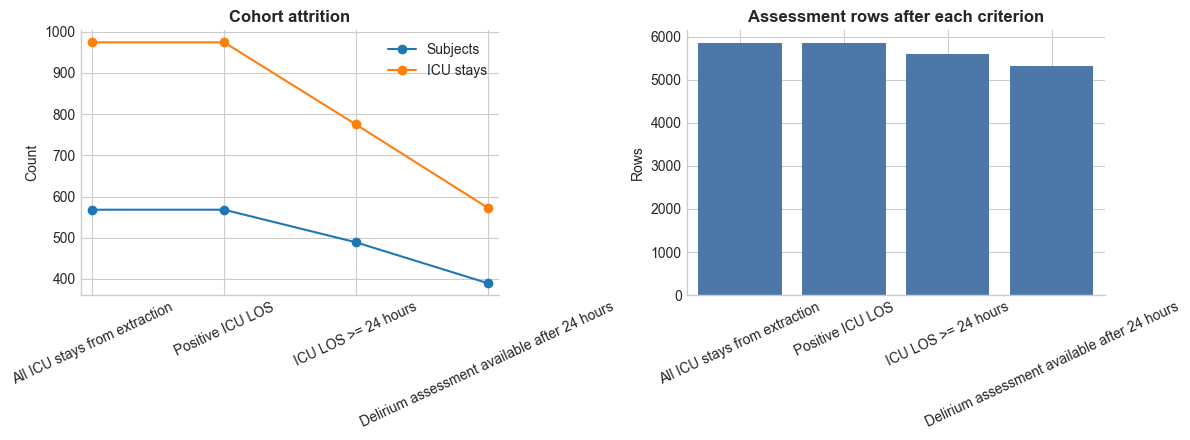

In [7]:
# Cohort attrition을 subject/stay/assessment 기준으로 시각화합니다.
cohort_flow_plot = cohort_flow.copy()
cohort_flow_plot['step_label'] = cohort_flow_plot['step'].str.replace(r'^\d+\. ', '', regex=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(cohort_flow_plot['step_label'], cohort_flow_plot['n_subjects'], marker='o', label='Subjects')
axes[0].plot(cohort_flow_plot['step_label'], cohort_flow_plot['n_stays'], marker='o', label='ICU stays')
axes[0].set_title('Cohort attrition')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()

axes[1].bar(cohort_flow_plot['step_label'], cohort_flow_plot['assessment_rows'], color='#4C78A8')
axes[1].set_title('Assessment rows after each criterion')
axes[1].set_ylabel('Rows')
axes[1].tick_params(axis='x', rotation=25)

for ax in axes:
    ax.margins(x=0.03)

plt.tight_layout()
plt.show()


## EDA: 환자 기본정보

In [8]:
# 범주형 기본정보는 subject 안에서 가장 흔한 값을 대표값으로 사용합니다.
def first_mode(values):
    mode_values = values.dropna().mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]

# subject-level 요약 테이블을 만듭니다.
subject_summary = (
    cohort_final
    .sort_values(['subject_id', 'intime'])
    .groupby('subject_id')
    .agg(
        ever_delirium=('ever_delirium', 'max'),
        n_stays=('stay_id', 'nunique'),
        first_age=('anchor_age', 'first'),
        gender=('gender', 'first'),
        race=('race', first_mode),
        admission_type=('admission_type', first_mode),
        first_intime=('intime', 'min'),
        last_outtime=('outtime', 'max'),
        total_icu_los_hours=('icu_los_hours', 'sum'),
    )
    .reset_index()
)

stay_summary = cohort_final[['subject_id', 'stay_id', 'anchor_age', 'gender', 'race', 'admission_type', 'icu_los_hours', 'ever_delirium']].copy()

print('=== Cohort overview ===')
print(f"Subjects: {subject_summary['subject_id'].nunique():,}")
print(f"Stays: {cohort_final['stay_id'].nunique():,}")
print(f"ICU stays per subject: median={subject_summary['n_stays'].median():.1f}, IQR={subject_summary['n_stays'].quantile(0.25):.1f}-{subject_summary['n_stays'].quantile(0.75):.1f}")
print(f"Parkinson cohort period: {cohort_final['intime'].min()} to {cohort_final['outtime'].max()}")

print()
print('=== ever_delirium 분포 (subject-level) ===')
print(subject_summary['ever_delirium'].value_counts().sort_index())
print((subject_summary['ever_delirium'].value_counts(normalize=True).sort_index() * 100).round(2))

print()
print('=== Subject-level numeric summary ===')
display(subject_summary[['first_age', 'n_stays', 'total_icu_los_hours']].describe())

print()
print('=== Subject-level summary by ever_delirium ===')
display(subject_summary.groupby('ever_delirium')[['first_age', 'n_stays', 'total_icu_los_hours']].describe())

print()
print('=== Gender by ever_delirium (%) ===')
display((pd.crosstab(subject_summary['ever_delirium'], subject_summary['gender'], normalize='index') * 100).round(1))

print()
print('=== Admission type by ever_delirium (%) ===')
display((pd.crosstab(stay_summary['ever_delirium'], stay_summary['admission_type'], normalize='index') * 100).round(1))


=== Cohort overview ===
Subjects: 390
Stays: 573
ICU stays per subject: median=1.0, IQR=1.0-1.0
Parkinson cohort period: 2110-12-20 02:37:25 to 2212-10-16 11:44:12

=== ever_delirium 분포 (subject-level) ===
ever_delirium
0    137
1    253
Name: count, dtype: int64
ever_delirium
0    35.13
1    64.87
Name: proportion, dtype: float64

=== Subject-level numeric summary ===


,first_age,n_stays,total_icu_los_hours
count,390.000000,390.000000,390.000000
mean,73.120513,1.469231,198.156521
std,10.603552,1.369077,313.452746
min,24.000000,1.000000,27.247500
25%,67.250000,1.000000,58.555972
50%,74.000000,1.000000,100.638056
75%,80.000000,1.000000,208.284375
max,91.000000,19.000000,4047.868889



=== Subject-level summary by ever_delirium ===


first_age                                                      \
                  count       mean        std   min   25%   50%   75%   max   
ever_delirium                                                                 
0                 137.0  73.481752  10.277833  38.0  69.0  75.0  80.0  91.0   
1                 253.0  72.924901  10.790864  24.0  67.0  74.0  80.0  91.0   

              n_stays            ...            total_icu_los_hours  \
                count      mean  ...  75%   max               count   
ever_delirium                    ...                                  
0               137.0  1.167883  ...  1.0   4.0               137.0   
1               253.0  1.632411  ...  2.0  19.0               253.0   

                                                                         \
                     mean         std        min        25%         50%   
ever_delirium                                                             
0               87.633863   69.933125  27.247500  43.764444   68.261111   
1              258.004758  372.547295  30.466667  74.011111  138.673056   

                                        
                      75%          max  
ever_delirium                           
0              107.894722   513.080000  
1              309.576389  4047.868889  

[2 rows x 24 columns]


=== Gender by ever_delirium (%) ===


gender,F,M
ever_delirium,,
0,30.7,69.3
1,35.2,64.8



=== Admission type by ever_delirium (%) ===


admission_type,DIRECT EMER.,DIRECT OBSERVATION,ELECTIVE,EU OBSERVATION,EW EMER.,OBSERVATION ADMIT,SURGICAL SAME DAY ADMISSION,URGENT
ever_delirium,,,,,,,,
0,3.1,0.0,3.1,0.0,37.5,30.0,8.8,17.5
1,1.7,0.2,1.2,0.2,51.8,27.6,3.4,13.8


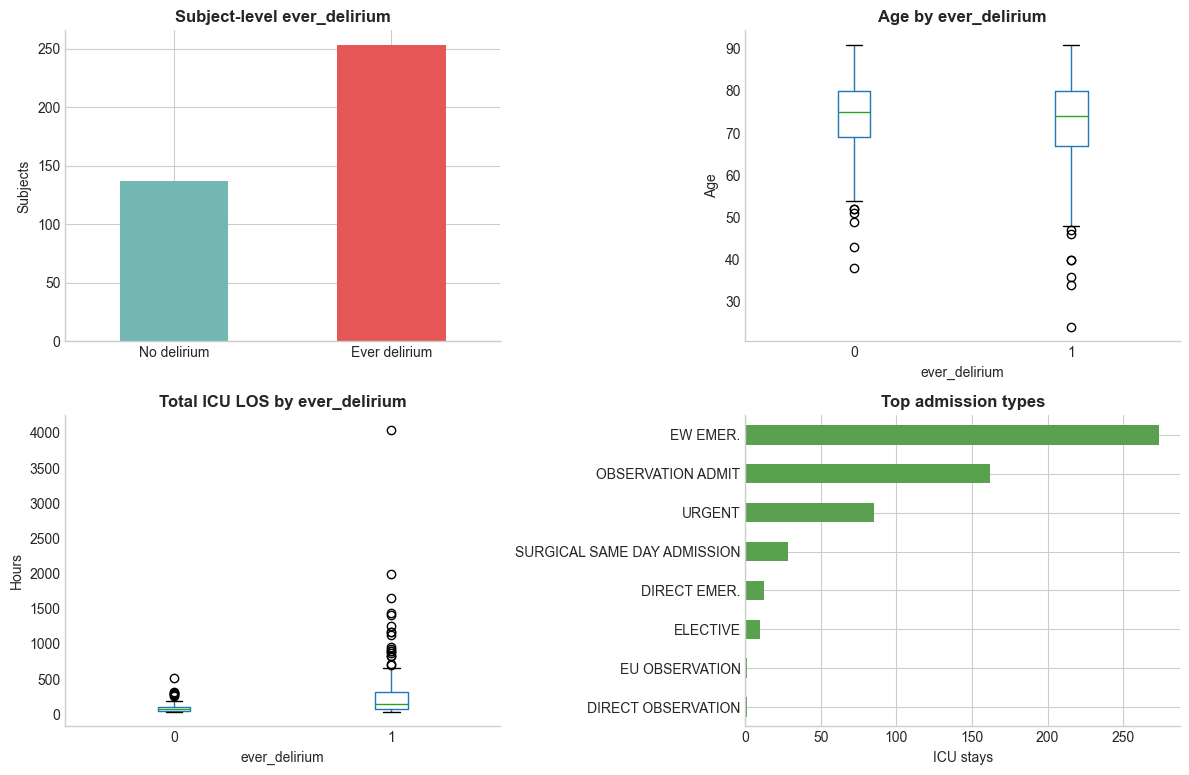

In [9]:
# 환자 기본정보와 ever_delirium 분포를 시각화합니다.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

subject_summary['ever_delirium'].value_counts().sort_index().rename({0: 'No delirium', 1: 'Ever delirium'}).plot(
    kind='bar', ax=axes[0, 0], color=['#72B7B2', '#E45756']
)
axes[0, 0].set_title('Subject-level ever_delirium')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Subjects')
axes[0, 0].tick_params(axis='x', rotation=0)

subject_summary.boxplot(column='first_age', by='ever_delirium', ax=axes[0, 1], grid=False)
axes[0, 1].set_title('Age by ever_delirium')
axes[0, 1].set_xlabel('ever_delirium')
axes[0, 1].set_ylabel('Age')

subject_summary.boxplot(column='total_icu_los_hours', by='ever_delirium', ax=axes[1, 0], grid=False)
axes[1, 0].set_title('Total ICU LOS by ever_delirium')
axes[1, 0].set_xlabel('ever_delirium')
axes[1, 0].set_ylabel('Hours')

stay_summary['admission_type'].value_counts().head(8).sort_values().plot(kind='barh', ax=axes[1, 1], color='#59A14F')
axes[1, 1].set_title('Top admission types')
axes[1, 1].set_xlabel('ICU stays')
axes[1, 1].set_ylabel('')

fig.suptitle('')
plt.tight_layout()
plt.show()


## EDA: 섬망 평가 주기

Assessment 횟수, assessment 간격, 첫 assessment까지 걸린 시간, ICU hour/day당 assessment 빈도를 확인합니다.


In [10]:
# delirium 값이 있는 row만 assessment 시점으로 사용합니다.
assessments = (
    timeseries_cohort
    .loc[timeseries_cohort['delirium'].notna(), ['subject_id', 'stay_id', 'bin', 'hours', 'delirium', 'ever_delirium']]
    .rename(columns={'bin': 'assessment_bin'})
    .sort_values(['stay_id', 'assessment_bin'])
    .reset_index(drop=True)
)

# stay/subject별 assessment count와 assessment 간격을 계산합니다.
assessment_counts_by_stay = assessments.groupby('stay_id').size().rename('assessment_count').reset_index()
assessment_counts_by_subject = assessments.groupby('subject_id').size().rename('assessment_count').reset_index()
assessment_intervals = assessments.groupby('stay_id')['hours'].diff().dropna()
first_assessment_hours = assessments.groupby('stay_id')['hours'].min().rename('first_assessment_hour').reset_index()
assessment_rate = assessment_counts_by_stay.merge(cohort_final[['stay_id', 'icu_los_hours']], on='stay_id', how='left')
assessment_rate['assessments_per_icu_day'] = assessment_rate['assessment_count'] / (assessment_rate['icu_los_hours'] / 24)
assessment_rate['assessments_per_icu_hour'] = assessment_rate['assessment_count'] / assessment_rate['icu_los_hours']

print('=== Delirium assessment rows ===')
print(f"Rows: {len(assessments):,}")
print(f"Stays with assessment: {assessments['stay_id'].nunique():,}")
print(f"Subjects with assessment: {assessments['subject_id'].nunique():,}")
print()
print('Assessment outcome distribution:')
print(assessments['delirium'].value_counts().sort_index())

print()
print('=== Assessment count by stay ===')
display(assessment_counts_by_stay['assessment_count'].describe())

print()
print('=== Assessment count by subject ===')
display(assessment_counts_by_subject['assessment_count'].describe())

print()
print('=== Assessment interval hours within stay ===')
display(assessment_intervals.describe())
print(f"Median/IQR: {assessment_intervals.median():.2f} hours / {assessment_intervals.quantile(0.25):.2f}-{assessment_intervals.quantile(0.75):.2f}")

print()
print('=== First assessment hour within ICU stay ===')
display(first_assessment_hours['first_assessment_hour'].describe())

print()
print('=== Assessment frequency ===')
display(assessment_rate[['assessments_per_icu_hour', 'assessments_per_icu_day']].describe())


=== Delirium assessment rows ===
Rows: 5,320
Stays with assessment: 573
Subjects with assessment: 390

Assessment outcome distribution:
delirium
0.0    3473
1.0    1847
Name: count, dtype: int64

=== Assessment count by stay ===


count    573.000000
mean       9.284468
std       10.418400
min        1.000000
25%        4.000000
50%        6.000000
75%       10.000000
max      107.000000
Name: assessment_count, dtype: float64


=== Assessment count by subject ===


count    390.000000
mean      13.641026
std       18.858541
min        1.000000
25%        4.000000
50%        8.000000
75%       15.750000
max      196.000000
Name: assessment_count, dtype: float64


=== Assessment interval hours within stay ===


count    4747.000000
mean       13.487645
std        15.348510
min         0.216667
25%         4.150000
50%        11.516667
75%        13.683333
max       323.983333
Name: hours, dtype: float64

Median/IQR: 11.52 hours / 4.15-13.68

=== First assessment hour within ICU stay ===


count    573.000000
mean       9.942422
std       15.052990
min        0.037500
25%        0.904167
50%        3.336389
75%       13.133333
max      125.383333
Name: first_assessment_hour, dtype: float64


=== Assessment frequency ===


,assessments_per_icu_hour,assessments_per_icu_day
count,573.000000,573.000000
mean,0.079598,1.910363
std,0.038711,0.929069
min,0.005982,0.143578
25%,0.053460,1.283041
50%,0.075649,1.815580
75%,0.101294,2.431058
max,0.283474,6.803388


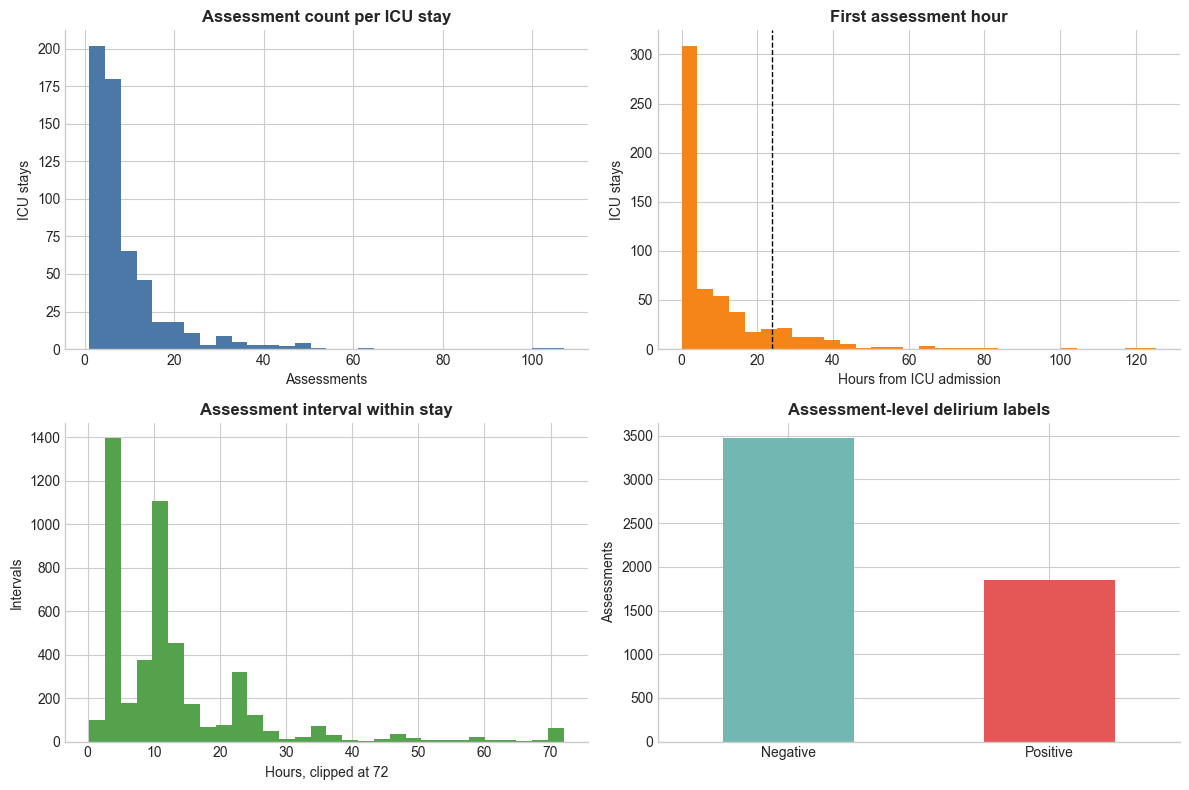

In [11]:
# Assessment 빈도와 timing을 시각화합니다.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

assessment_counts_by_stay['assessment_count'].plot(kind='hist', bins=30, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Assessment count per ICU stay')
axes[0, 0].set_xlabel('Assessments')
axes[0, 0].set_ylabel('ICU stays')

first_assessment_hours['first_assessment_hour'].plot(kind='hist', bins=30, ax=axes[0, 1], color='#F58518')
axes[0, 1].axvline(24, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('First assessment hour')
axes[0, 1].set_xlabel('Hours from ICU admission')
axes[0, 1].set_ylabel('ICU stays')

assessment_intervals.clip(upper=72).plot(kind='hist', bins=30, ax=axes[1, 0], color='#54A24B')
axes[1, 0].set_title('Assessment interval within stay')
axes[1, 0].set_xlabel('Hours, clipped at 72')
axes[1, 0].set_ylabel('Intervals')

assessments['delirium'].value_counts().sort_index().rename({0: 'Negative', 1: 'Positive'}).plot(
    kind='bar', ax=axes[1, 1], color=['#72B7B2', '#E45756']
)
axes[1, 1].set_title('Assessment-level delirium labels')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Assessments')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## EDA: 검사실(lab) 측정 주기

Lab feature별 측정 횟수, 측정 간격, stay/subject coverage와 전체 lab 측정 간격을 확인합니다.


In [12]:
# long-format 이벤트에서 lab row만 골라 측정 주기를 계산합니다.
all_events_for_eda = pd.read_csv(TRANSFORM_DIR / 'all_events_filtered.csv')
all_events_for_eda['charttime'] = pd.to_datetime(all_events_for_eda['charttime'], errors='coerce')
lab_events = all_events_for_eda[
    all_events_for_eda['source_table'].eq('labevents')
    & all_events_for_eda['stay_id'].isin(cohort_stay_ids)
    & all_events_for_eda['charttime'].notna()
].copy()

lab_events = lab_events.merge(
    cohort_final[['stay_id', 'subject_id', 'intime', 'outtime']],
    on=['stay_id', 'subject_id'],
    how='inner',
)
lab_events['lab_hour'] = (lab_events['charttime'] - lab_events['intime']).dt.total_seconds() / 3600
lab_events = lab_events[(lab_events['lab_hour'] >= 0) & (lab_events['charttime'] <= lab_events['outtime'])].copy()

# feature별 측정 횟수와 coverage를 요약합니다.
lab_feature_counts = (
    lab_events
    .groupby('feature_name')
    .agg(
        n_measurements=('feature_name', 'size'),
        n_stays=('stay_id', 'nunique'),
        n_subjects=('subject_id', 'nunique'),
    )
    .reset_index()
)
lab_feature_counts['stay_coverage_pct'] = lab_feature_counts['n_stays'] / cohort_final['stay_id'].nunique() * 100
lab_feature_counts['subject_coverage_pct'] = lab_feature_counts['n_subjects'] / cohort_final['subject_id'].nunique() * 100

# 같은 stay 안에서 같은 lab feature가 반복 측정된 간격을 계산합니다.
lab_sorted = lab_events.sort_values(['stay_id', 'feature_name', 'charttime'])
lab_sorted['interval_hours'] = lab_sorted.groupby(['stay_id', 'feature_name'])['charttime'].diff().dt.total_seconds() / 3600
lab_interval_summary = (
    lab_sorted
    .dropna(subset=['interval_hours'])
    .groupby('feature_name')['interval_hours']
    .agg(
        interval_n='count',
        interval_median_hours='median',
        interval_q1_hours=lambda x: x.quantile(0.25),
        interval_q3_hours=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

lab_summary = (
    lab_feature_counts
    .merge(lab_interval_summary, on='feature_name', how='left')
    .sort_values(['n_measurements', 'stay_coverage_pct'], ascending=False)
    .reset_index(drop=True)
)

# 어떤 lab이든 측정된 시점 기준의 전체 lab 간격도 함께 봅니다.
any_lab_times = lab_events[['stay_id', 'charttime']].drop_duplicates().sort_values(['stay_id', 'charttime']).copy()
any_lab_intervals = any_lab_times.groupby('stay_id')['charttime'].diff().dt.total_seconds().div(3600).dropna()

print('=== Lab measurement overview ===')
print(f"Lab rows: {len(lab_events):,}")
print(f"Lab features: {lab_events['feature_name'].nunique():,}")
print(f"Stays with any lab: {lab_events['stay_id'].nunique():,} / {cohort_final['stay_id'].nunique():,}")
print(f"Subjects with any lab: {lab_events['subject_id'].nunique():,} / {cohort_final['subject_id'].nunique():,}")

print()
print('=== Lab feature measurement summary ===')
display(lab_summary)

print()
print('=== Any-lab interval hours within stay ===')
display(any_lab_intervals.describe())
print(f"Median/IQR: {any_lab_intervals.median():.2f} hours / {any_lab_intervals.quantile(0.25):.2f}-{any_lab_intervals.quantile(0.75):.2f}")


=== Lab measurement overview ===
Lab rows: 89,369
Lab features: 28
Stays with any lab: 564 / 573
Subjects with any lab: 386 / 390

=== Lab feature measurement summary ===


,feature_name,n_measurements,n_stays,n_subjects,stay_coverage_pct,subject_coverage_pct,interval_n,interval_median_hours,interval_q1_hours,interval_q3_hours
0,sodium,5058,564,386,98.429319,98.974359,4494,12.000000,7.220833,22.416667
1,potassium,4988,564,386,98.429319,98.974359,4424,12.158333,7.500000,22.683333
2,chloride,4911,564,386,98.429319,98.974359,4347,12.383333,7.833333,22.891667
3,bicarbonate,4810,564,386,98.429319,98.974359,4246,12.650000,8.275000,23.066667
4,creatinine,4799,564,386,98.429319,98.974359,4235,12.650000,8.483333,23.050000
5,BUN,4793,564,386,98.429319,98.974359,4229,12.666667,8.500000,23.066667
6,glucose,4744,564,386,98.429319,98.974359,4180,12.775000,8.262500,23.250000
7,magnesium,4667,563,385,98.254799,98.717949,4104,12.816667,8.533333,23.216667
8,hematocrit,4609,564,386,98.429319,98.974359,4045,14.050000,6.766667,23.816667
9,phosphate,4583,561,384,97.905759,98.461538,4022,13.033333,8.833333,23.366667



=== Any-lab interval hours within stay ===


count    9150.000000
mean        7.208362
std         8.045725
min         0.016667
25%         1.533333
50%         5.316667
75%         9.829167
max       145.250000
Name: charttime, dtype: float64

Median/IQR: 5.32 hours / 1.53-9.83


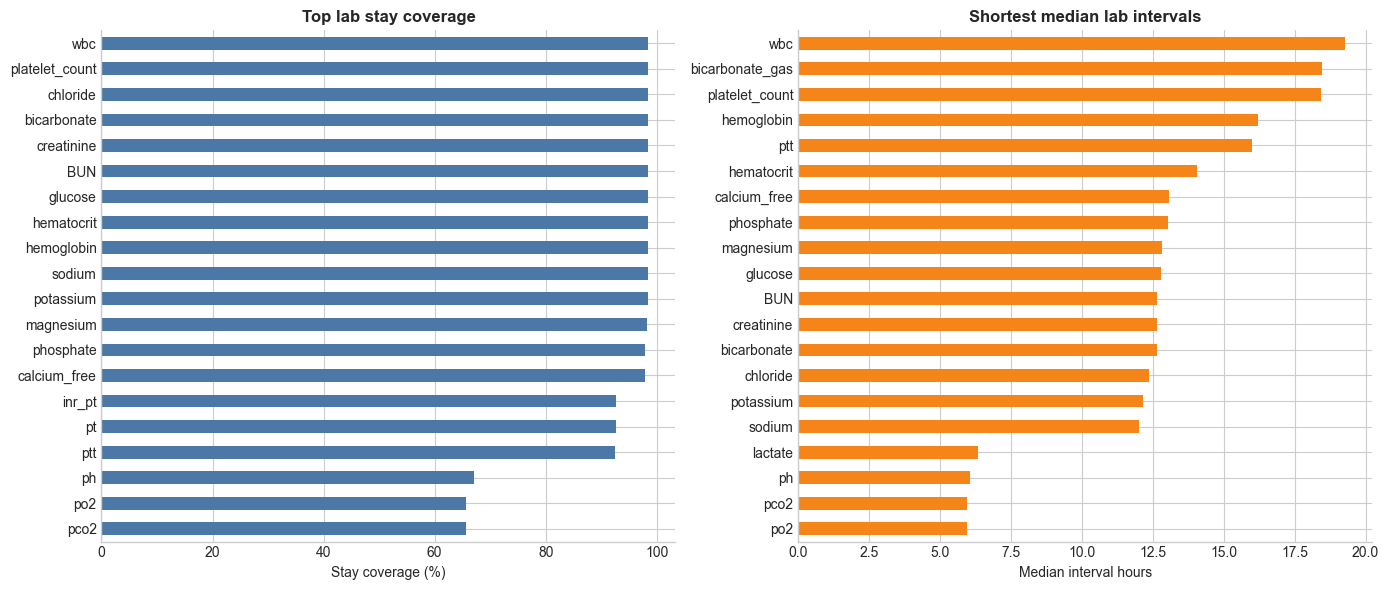

In [13]:
# Lab coverage와 반복 측정 간격을 시각화합니다.
top_lab_coverage = lab_summary.sort_values('stay_coverage_pct', ascending=False).head(20).sort_values('stay_coverage_pct')
top_lab_interval = (
    lab_summary
    .dropna(subset=['interval_median_hours'])
    .sort_values('interval_median_hours')
    .head(20)
    .sort_values('interval_median_hours')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_lab_coverage.plot(x='feature_name', y='stay_coverage_pct', kind='barh', ax=axes[0], legend=False, color='#4C78A8')
axes[0].set_title('Top lab stay coverage')
axes[0].set_xlabel('Stay coverage (%)')
axes[0].set_ylabel('')

if len(top_lab_interval) > 0:
    top_lab_interval.plot(x='feature_name', y='interval_median_hours', kind='barh', ax=axes[1], legend=False, color='#F58518')
    axes[1].set_title('Shortest median lab intervals')
    axes[1].set_xlabel('Median interval hours')
    axes[1].set_ylabel('')
else:
    axes[1].text(0.5, 0.5, 'No repeated lab intervals', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## EDA: Feature missingness

Hourly timeseries 기준 feature별 관측률을 확인합니다. Static identifier/time/outcome 컬럼은 제외하고 봅니다.


,feature_name,observed_rows,missing_rows,observed_pct,missing_pct
0,age,74230,0,100.000000,0.000000
1,benzodiazepine,74230,0,100.000000,0.000000
2,procedure_invasive_ventilation,74230,0,100.000000,0.000000
3,vasopressor,74230,0,100.000000,0.000000
4,sedatives,74230,0,100.000000,0.000000
5,opioid,74230,0,100.000000,0.000000
6,maob_inhibitor,74230,0,100.000000,0.000000
7,levodopa_related,74230,0,100.000000,0.000000
8,los_hours,74230,0,100.000000,0.000000
9,dopamine_agonist,74230,0,100.000000,0.000000


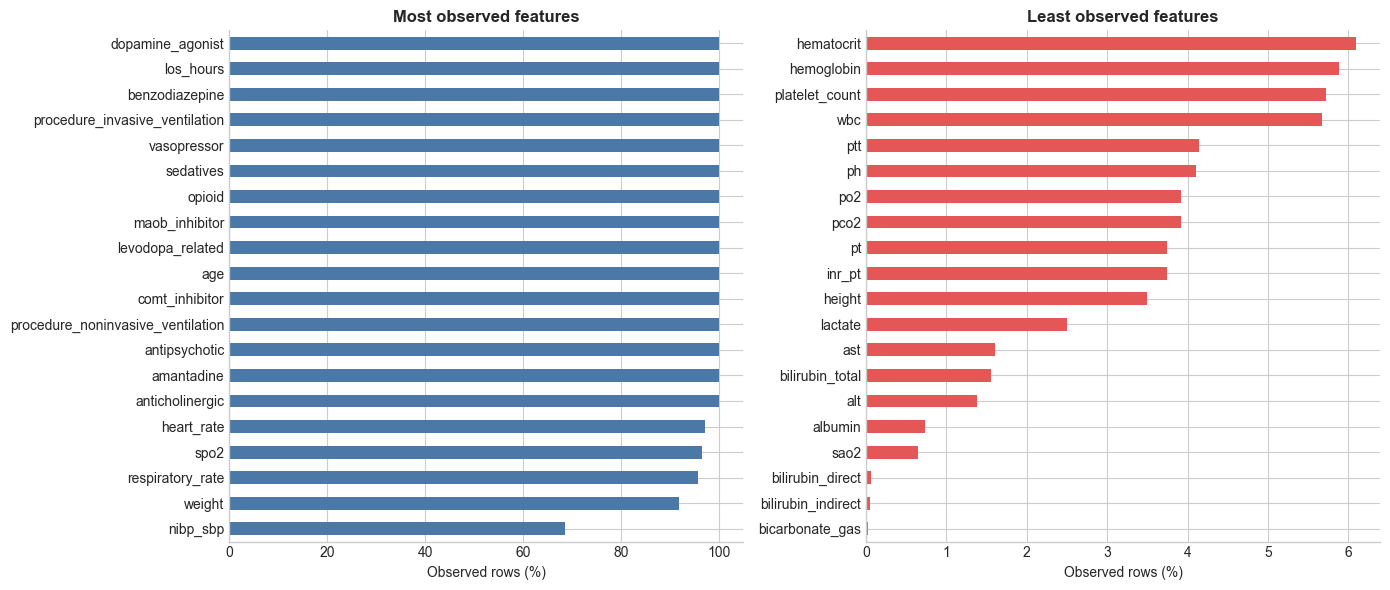

In [14]:
# Hourly timeseries의 feature missingness를 요약하고 시각화합니다.
non_feature_cols = {
    'subject_id', 'hadm_id', 'stay_id', 'bin', 'hours', 'intime', 'outtime',
    'admittime', 'dischtime', 'deathtime', 'ever_delirium', 'split', 'race',
    'admission_type', 'gender', 'anchor_age', 'icu_los_hours', 'delirium'
}
feature_cols = [col for col in timeseries_cohort.columns if col not in non_feature_cols]

feature_missing = pd.DataFrame({
    'feature_name': feature_cols,
    'observed_rows': timeseries_cohort[feature_cols].notna().sum().values,
})
feature_missing['missing_rows'] = len(timeseries_cohort) - feature_missing['observed_rows']
feature_missing['observed_pct'] = feature_missing['observed_rows'] / len(timeseries_cohort) * 100
feature_missing['missing_pct'] = 100 - feature_missing['observed_pct']
feature_missing = feature_missing.sort_values('observed_pct', ascending=False).reset_index(drop=True)

display(feature_missing)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
feature_missing.head(20).sort_values('observed_pct').plot(
    x='feature_name', y='observed_pct', kind='barh', ax=axes[0], legend=False, color='#4C78A8'
)
axes[0].set_title('Most observed features')
axes[0].set_xlabel('Observed rows (%)')
axes[0].set_ylabel('')

feature_missing.tail(20).sort_values('observed_pct').plot(
    x='feature_name', y='observed_pct', kind='barh', ax=axes[1], legend=False, color='#E45756'
)
axes[1].set_title('Least observed features')
axes[1].set_xlabel('Observed rows (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
